Jako algorytm atakujący chcemy wyciągnąć informacje z naszego anonimowego zapisu zbioru danych. Przeprowadź Atak Skośności (Skewness Attack):

- Wybierz jedną grupę $(EC_{i})$, do której należy Twoja ofiara.
- Wygeneruj dwa histogramy:
    - Histogram Globalny $P_{G}(s)$: Rozkład cechy wrażliwej $S$ w całej bazie danych.
    - Histogram Lokalny $P_{i}(s)$: Rozkład tej samej cechy, ale tylko w wybranej grupie $(EC_{i})$.
Jeśli histogram lokalny jest znacząco różny od globalnego przy zadanym progu pewności tau: $|P_{i}(s) - P_{G}(s)| > \tau$ - **Atak uznajemy za udany**


In [1]:
import pandas as pd
import numpy as np
import kagglehub
import random

path = kagglehub.dataset_download("mirichoi0218/insurance")
df = pd.read_csv(path + '/insurance.csv')

quasi_ids = ['age', 'sex', 'region', 'children']
sensitive_column = 'charges'

l_param = 7 

df['charges'] = (df['charges'] // 200) * 200

for col in ['sex', 'region', 'smoker']:
    df[col] = df[col].astype('category')

def get_spans(df, partition):
    spans = {}
    for col in quasi_ids:
        if df[col].dtype.name == 'category':
            spans[col] = len(df[col][partition].unique())
        else:
            spans[col] = df[col][partition].max() - df[col][partition].min()
    return spans

def split(df, partition, column):
    dfp = df[column][partition]
    if df[column].dtype.name == 'category':
        values = dfp.unique()
        lv = set(values[:len(values)//2])
        rv = set(values[len(values)//2:])
        return dfp.index[dfp.isin(lv)], dfp.index[dfp.isin(rv)]
    else:
        median = dfp.median()
        return dfp.index[dfp < median], dfp.index[dfp >= median]
    
def is_k_anonymous(df, lp, rp, k):
    if len(lp) >= k and len(rp) < k:
        return False
    return True 

def is_l_diverse_entropy(df, partition, l):
    if len(partition) == 0:
        return False
    
    sensitive_values = df.loc[partition, sensitive_column]
        
    counts = sensitive_values.value_counts()
    probs = counts / len(sensitive_values)
    
    entropy = -np.sum(probs * np.log(probs))
        
    return entropy >= np.log(l)

def is_l_diverse(df, lp, rp, l):
    return is_l_diverse_entropy(df, lp, l) and is_l_diverse_entropy(df, rp, l)   

def mondrian(df, partition, k=10, l = 2):
    if len(partition) < 2*k:
        return [partition]

    spans = get_spans(df, partition)
    columns = list(spans.keys())
    random.shuffle(columns)

    for column in columns:
        lp, rp = split(df, partition, column)
        if is_k_anonymous(df, lp, rp, k) and is_l_diverse(df, lp, rp, l):
            return mondrian(df, lp, k, l) + mondrian(df, rp, k, l)
    return [partition]

finished_partitions = mondrian(df, df.index, k=25, l=l_param)

rows = []
for part in finished_partitions:
    group = df.loc[part]
    agg_vals = {}
    for col in quasi_ids:
        if df[col].dtype.name == 'category':
            agg_vals[col] = ", ".join(group[col].unique())
        else:
            agg_vals[col] = f"{group[col].min()}-{group[col].max()}"
    agg_vals['charges_mean'] = group['charges'].mean()
    agg_vals['count'] = len(group)
    rows.append(agg_vals)

df_summary = pd.DataFrame(rows)
df_summary

,age,sex,region,children,charges_mean,count
0,18-19,female,"southwest, northeast",0-5,5933.333333,30
1,18-19,female,"southeast, northwest",0-3,9683.333333,36
2,20-22,female,"northwest, northeast, southeast, southwest",0-5,6685.000000,40
3,23-25,female,"northeast, northwest, southeast, southwest",0-3,11043.902439,41
4,18-19,male,"southeast, northeast",0-3,8989.473684,38
5,20-25,male,"northeast, southeast",0-5,12124.444444,45
6,19-19,male,"southwest, northwest",0-2,8230.303030,33
7,20-25,male,"southwest, northwest",0-5,8032.558140,43
8,26-31,"male, female",southeast,0-3,10521.739130,46
9,26-31,"female, male",northwest,0-3,8246.153846,39


In [11]:
import matplotlib.pyplot as plt

def attack(df, tau=0.10):
    # 1) Wybierz losową ofiarę i znajdź jej klasę równoważności EC_i
    victim_idx = np.random.choice(df.index)
    victim_record = df.loc[victim_idx]

    victim_partition = None
    for part in finished_partitions:
        if victim_idx in part:
            victim_partition = part
            break

    if victim_partition is None:
        raise RuntimeError("Nie znaleziono grupy EC_i dla wybranej ofiary.")

    local_sensitive = df.loc[victim_partition, sensitive_column]
    global_sensitive = df[sensitive_column]

    # 2) Histogram globalny i lokalny (te same koszyki dla porównywalności)
    bins = np.histogram_bin_edges(global_sensitive, bins=20)
    global_hist, _ = np.histogram(global_sensitive, bins=bins)
    local_hist, _ = np.histogram(local_sensitive, bins=bins)

    # Znormalizowane rozkłady: P_G(s) i P_i(s)
    P_G = global_hist / global_hist.sum()
    P_i = local_hist / local_hist.sum()

    # 3) Test ataku skośności: max_s |P_i(s)-P_G(s)| > tau
    tau = 0.10
    diff = np.abs(P_i - P_G)
    max_diff = diff.max()
    attack_success = max_diff > tau


    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    axes[0].hist(global_sensitive, bins=bins, density=True, alpha=0.75, color="#1f77b4", edgecolor="black")
    axes[0].set_title("Histogram Globalny P_G(s)")
    axes[0].set_xlabel(sensitive_column)
    axes[0].set_ylabel("Gęstość")

    axes[1].hist(local_sensitive, bins=bins, density=True, alpha=0.75, color="#ff7f0e", edgecolor="black")
    axes[1].set_title("Histogram Lokalny P_i(s) (EC_i ofiary)")
    axes[1].set_xlabel(sensitive_column)

    plt.tight_layout()
    plt.show()


    print(f"Ofiara (index): {victim_idx}")
    print("Ofiara (QI):", victim_record[quasi_ids].to_dict())
    print(f"Rozmiar EC_i: {len(victim_partition)}")
    print(f"tau = {tau:.2f}")
    print(f"max_s |P_i(s)-P_G(s)| = {max_diff:.4f}")
    print("Wynik ataku:", "UDANY" if attack_success else "NIEUDANY")

    # Podgląd największych odchyleń między P_i i P_G
    bin_labels = [f"[{int(bins[i])}, {int(bins[i+1])})" for i in range(len(bins) - 1)]
    diff_df = pd.DataFrame({
        "bin": bin_labels,
        "P_G": P_G,
        "P_i": P_i,
        "abs_diff": diff
    }).sort_values("abs_diff", ascending=False)

    print(diff_df.head(10))

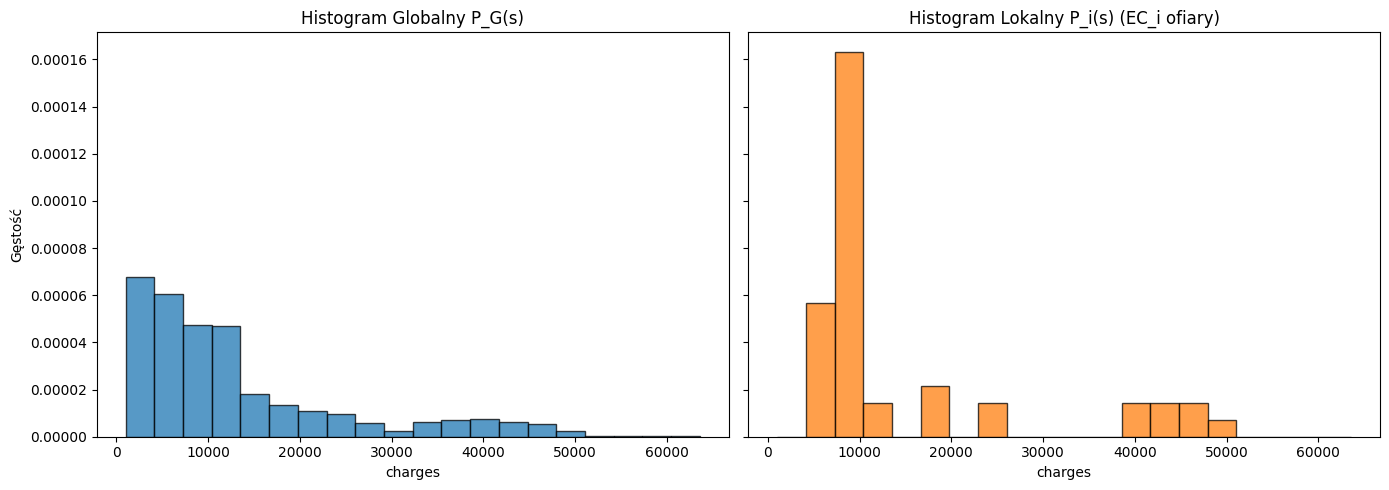

Ofiara (index): 800
Ofiara (QI): {'age': 42, 'sex': 'female', 'region': 'southeast', 'children': 1}
Rozmiar EC_i: 45
tau = 0.10
max_s |P_i(s)-P_G(s)| = 0.3631
Wynik ataku: UDANY
               bin       P_G       P_i  abs_diff
2    [7260, 10390)  0.147982  0.511111  0.363129
0     [1000, 4130)  0.211510  0.000000  0.211510
3   [10390, 13520)  0.147235  0.044444  0.102790
4   [13520, 16650)  0.056054  0.000000  0.056054
6   [19780, 22910)  0.033632  0.000000  0.033632
14  [44820, 47950)  0.016442  0.044444  0.028002
13  [41690, 44820)  0.020179  0.044444  0.024265
5   [16650, 19780)  0.042601  0.066667  0.024066
11  [35430, 38560)  0.022422  0.000000  0.022422
12  [38560, 41690)  0.023916  0.044444  0.020528


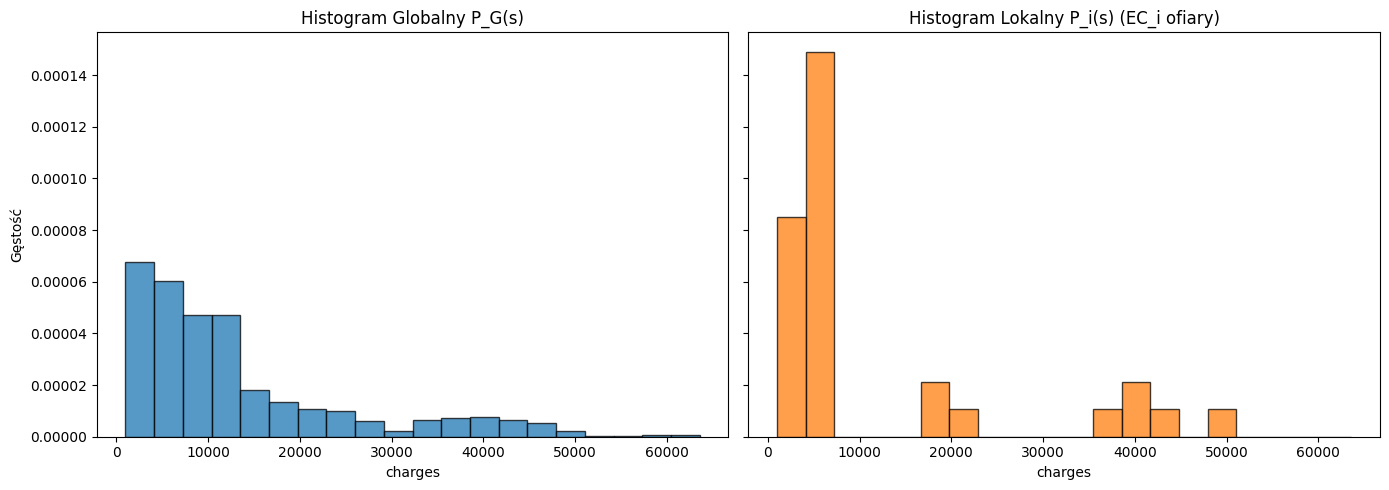

Ofiara (index): 608
Ofiara (QI): {'age': 28, 'sex': 'male', 'region': 'northeast', 'children': 2}
Rozmiar EC_i: 30
tau = 0.10
max_s |P_i(s)-P_G(s)| = 0.2776
Wynik ataku: UDANY
               bin       P_G       P_i  abs_diff
1     [4130, 7260)  0.189088  0.466667  0.277578
2    [7260, 10390)  0.147982  0.000000  0.147982
3   [10390, 13520)  0.147235  0.000000  0.147235
4   [13520, 16650)  0.056054  0.000000  0.056054
0     [1000, 4130)  0.211510  0.266667  0.055157
12  [38560, 41690)  0.023916  0.066667  0.042750
7   [22910, 26040)  0.030643  0.000000  0.030643
15  [47950, 51080)  0.007474  0.033333  0.025859
5   [16650, 19780)  0.042601  0.066667  0.024066
10  [32300, 35430)  0.020179  0.000000  0.020179


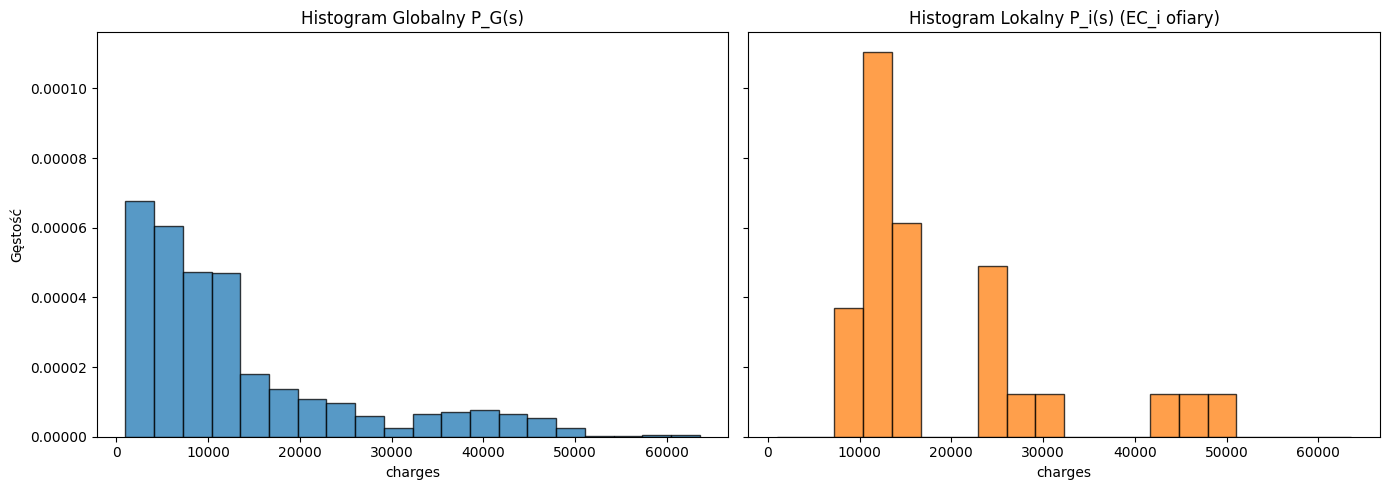

Ofiara (index): 659
Ofiara (QI): {'age': 57, 'sex': 'female', 'region': 'northeast', 'children': 4}
Rozmiar EC_i: 26
tau = 0.10
max_s |P_i(s)-P_G(s)| = 0.2115
Wynik ataku: UDANY
               bin       P_G       P_i  abs_diff
0     [1000, 4130)  0.211510  0.000000  0.211510
3   [10390, 13520)  0.147235  0.346154  0.198919
1     [4130, 7260)  0.189088  0.000000  0.189088
4   [13520, 16650)  0.056054  0.192308  0.136254
7   [22910, 26040)  0.030643  0.153846  0.123203
5   [16650, 19780)  0.042601  0.000000  0.042601
6   [19780, 22910)  0.033632  0.000000  0.033632
2    [7260, 10390)  0.147982  0.115385  0.032597
15  [47950, 51080)  0.007474  0.038462  0.030988
9   [29170, 32300)  0.007474  0.038462  0.030988


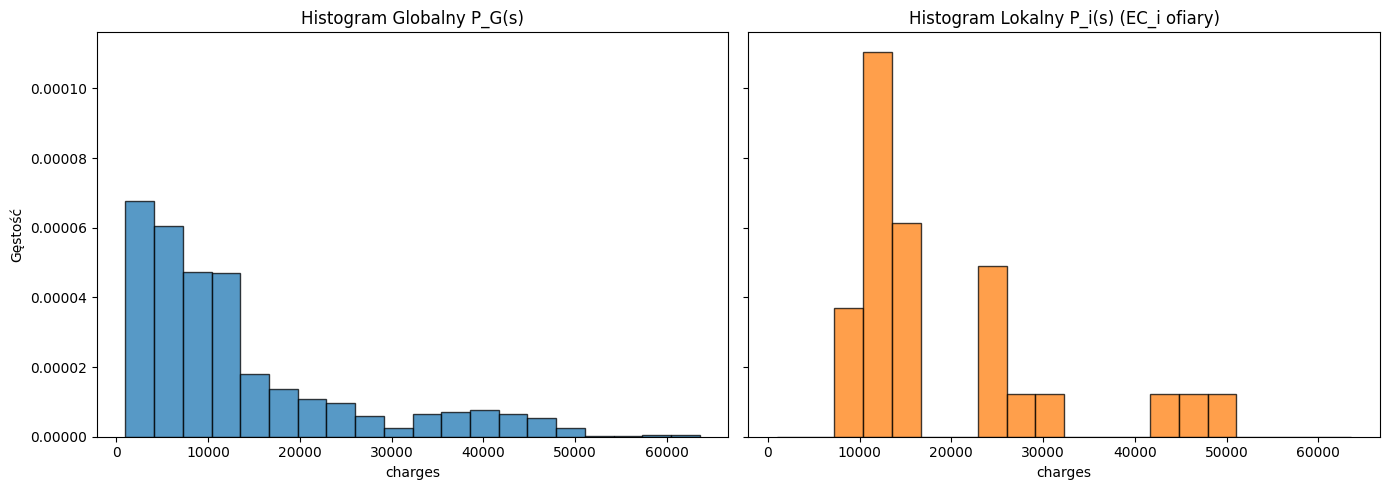

Ofiara (index): 267
Ofiara (QI): {'age': 59, 'sex': 'female', 'region': 'northeast', 'children': 3}
Rozmiar EC_i: 26
tau = 0.10
max_s |P_i(s)-P_G(s)| = 0.2115
Wynik ataku: UDANY
               bin       P_G       P_i  abs_diff
0     [1000, 4130)  0.211510  0.000000  0.211510
3   [10390, 13520)  0.147235  0.346154  0.198919
1     [4130, 7260)  0.189088  0.000000  0.189088
4   [13520, 16650)  0.056054  0.192308  0.136254
7   [22910, 26040)  0.030643  0.153846  0.123203
5   [16650, 19780)  0.042601  0.000000  0.042601
6   [19780, 22910)  0.033632  0.000000  0.033632
2    [7260, 10390)  0.147982  0.115385  0.032597
15  [47950, 51080)  0.007474  0.038462  0.030988
9   [29170, 32300)  0.007474  0.038462  0.030988


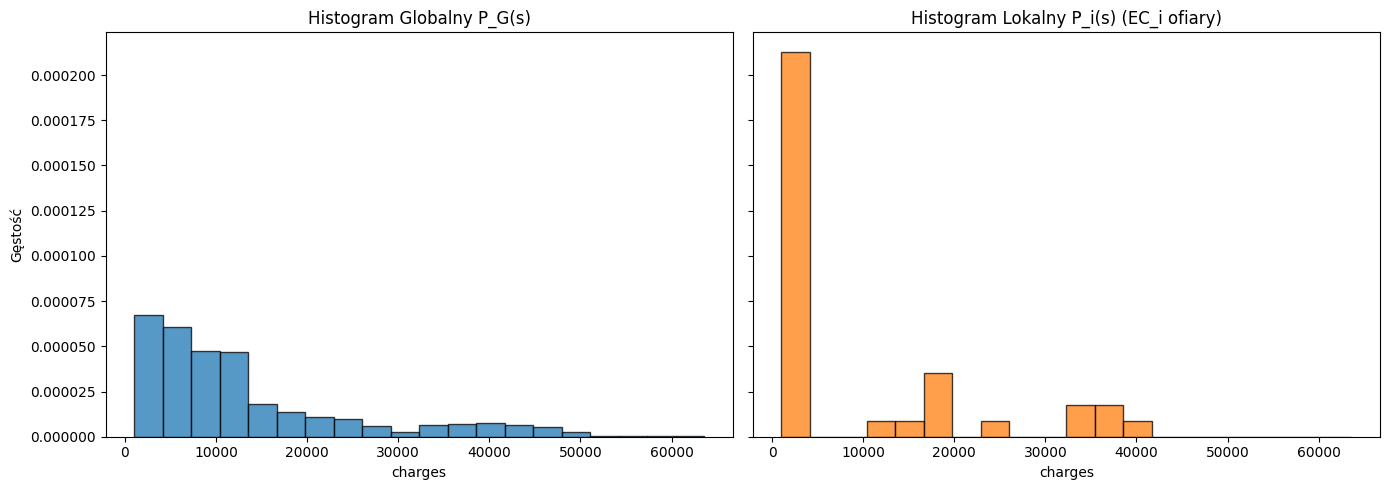

Ofiara (index): 399
Ofiara (QI): {'age': 18, 'sex': 'female', 'region': 'southeast', 'children': 0}
Rozmiar EC_i: 36
tau = 0.10
max_s |P_i(s)-P_G(s)| = 0.4552
Wynik ataku: UDANY
               bin       P_G       P_i  abs_diff
0     [1000, 4130)  0.211510  0.666667  0.455157
1     [4130, 7260)  0.189088  0.000000  0.189088
2    [7260, 10390)  0.147982  0.000000  0.147982
3   [10390, 13520)  0.147235  0.027778  0.119457
5   [16650, 19780)  0.042601  0.111111  0.068510
10  [32300, 35430)  0.020179  0.055556  0.035376
6   [19780, 22910)  0.033632  0.000000  0.033632
11  [35430, 38560)  0.022422  0.055556  0.033134
4   [13520, 16650)  0.056054  0.027778  0.028276
13  [41690, 44820)  0.020179  0.000000  0.020179


In [12]:
for _ in range(5):
    attack(df, tau=0.10)